# Arabic reviews classification (AraVec + MLP)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
df = pd.read_csv('Dataset.tsv', sep='\t')
print(df.shape)
df['label'].value_counts()


(99999, 2)


label
Positive    33333
Mixed       33333
Negative    33333
Name: count, dtype: int64

## Preprocessing
- remove urls, mentions, diacritics, tatweel
- normalize أ/إ/آ to ا, ى to ي, ة to ه (same as AraVec)
- collapse repeated letters (حلوووو to حلو)
- keep arabic letters only
- remove stopwords, but keep negations (لا, لم, ليس, ...)
- no stemming since AraVec vectors are for full words

In [ ]:
stopwords = set('''في من الى علي عن هذا هذه ذلك تلك التي الذي الذين هو هي هم انا نحن انت
كان كانت ان او ثم مع كل بعد قبل حتي عند و ف ب ل ك اي اذا قد لقد هناك هنا كما بين'''.split())

def preprocess(text):
    text = re.sub(r'http\S+|www\.\S+|@\w+', ' ', text)
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652\u0670]', '', text)
    text = text.replace('ـ', '')
    text = re.sub('[إأآٱ]', 'ا', text)
    text = text.replace('ى', 'ي').replace('ة', 'ه').replace('ؤ', 'و').replace('ئ', 'ي')
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = re.sub(r'[^\u0621-\u064A\s]', ' ', text)
    return [w for w in text.split() if w not in stopwords]

df['tokens'] = df['text'].apply(preprocess)
print(df['text'][0])
print(df['tokens'][0])


ممتاز نوعا ما . النظافة والموقع والتجهيز والشاطيء. المطعم
['ممتاز', 'نوعا', 'ما', 'النظافه', 'والموقع', 'والتجهيز', 'والشاطيء', 'المطعم']


## AraVec features
model: https://bakrianoo.ewr1.vultrobjects.com/aravec/full_uni_cbow_100_twitter.zip (unzipped into `aravec/`)

each review = mean + max of its word vectors (200 dims) 

example of the current folder strucutre of the project:
```
❯ tree .
.
├── arabic_reviews_aravec.ipynb
├── aravec
│   ├── full_uni_cbow_100_twitter.mdl
│   ├── full_uni_cbow_100_twitter.mdl.trainables.syn1neg.npy
│   ├── full_uni_cbow_100_twitter.mdl.wv.vectors.npy
│   └── full_uni_cbow_100_twitter.zip
└── Dataset.tsv

2 directories, 6 files
```

In [ ]:
wv = Word2Vec.load('aravec/full_uni_cbow_100_twitter.mdl').wv

def to_vec(tokens):
    vecs = [wv[w] for w in tokens if w in wv.key_to_index]
    if not vecs:
        return np.zeros(200)
    return np.concatenate([np.mean(vecs, axis=0), np.max(vecs, axis=0)])

X = np.vstack(df['tokens'].apply(to_vec))
y = df['label'].values
X.shape


(99999, 200)

## Split 90/10 and train

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(256, 128), alpha=1e-3, early_stopping=True, max_iter=50, random_state=0)
clf.fit(X_train, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(256, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",0
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating th

## Results

In [ ]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       Mixed       0.56      0.48      0.51      3333
    Negative       0.67      0.66      0.66      3333
    Positive       0.61      0.72      0.66      3334

    accuracy                           0.62     10000
   macro avg       0.61      0.62      0.61     10000
weighted avg       0.61      0.62      0.61     10000



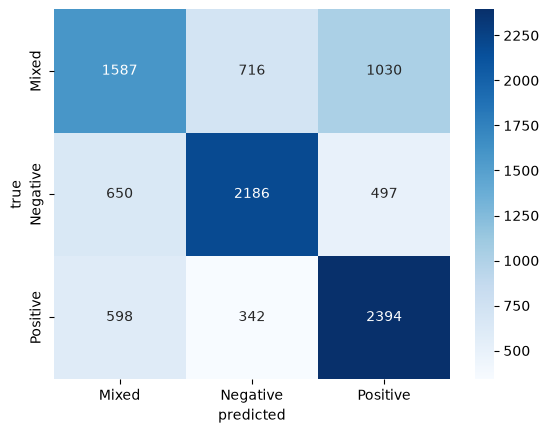

In [7]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('predicted')
plt.ylabel('true')
plt.show()


## New sentences

In [ ]:
sentences = [
    'الفندق رائع جدا والموظفين محترمين والاكل لذيذ',
    'تجربة سيئة للغاية، الغرفة وسخة والخدمة بطيئة ولن اكرر الزيارة',
    'الكتاب ممتع في البداية لكن النهاية كانت مخيبة للامال',
    'المكان جميل لكن الاسعار مرتفعة جدا',
    'اسوأ رواية قرأتها في حياتي، مضيعة للوقت',
    'من افضل الكتب التي قرأتها، انصح الجميع بقراءته',
]
print(any(s in set(df['text']) for s in sentences))  # make sure none are in the dataset

preds = clf.predict(scaler.transform(np.vstack([to_vec(preprocess(s)) for s in sentences])))
for s, p in zip(sentences, preds):
    print(p, '|', s)


False
Positive | الفندق رائع جدا والموظفين محترمين والاكل لذيذ
Negative | تجربة سيئة للغاية، الغرفة وسخة والخدمة بطيئة ولن اكرر الزيارة
Mixed | الكتاب ممتع في البداية لكن النهاية كانت مخيبة للامال
Positive | المكان جميل لكن الاسعار مرتفعة جدا
Negative | اسوأ رواية قرأتها في حياتي، مضيعة للوقت
Positive | من افضل الكتب التي قرأتها، انصح الجميع بقراءته
